# Phase 2 — EDA + Survival Analysis

With the data validated in Phase 1, we now look for the *patterns* the model will need to capture and the *segments* that matter for the cost-aware decision rule downstream.

**Sections:**
- A. Population overview
- B. Churn rates by categorical segment
- C. Kaplan-Meier survival curves — structural covariates
- C2. Landmark analysis — engagement_cohort (time-varying covariate)
- C3. Sensitivity check — landmark robustness
- D. Hazard by tenure month
- E. Engagement-trend distribution
- F. Tenure × cohort heatmap
- G. Verdict / Phase 3 handoff

> **Why both segment-rate analysis AND survival analysis?**
> Segment churn rates answer "which group has the highest 30-day churn right now?" Survival curves answer "how does churn risk evolve as a user ages?" The first informs targeting; the second informs *timing* — when to intervene in the lifecycle. Both feed the Phase 6 decision rule.

In [21]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers

FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_subscribers('../data/subscribers.csv')
print(f'Loaded {len(df):,} subscribers x {df.shape[1]} columns')

Loaded 50,000 subscribers x 28 columns


## A. Population overview

In [22]:
for col in ['plan_tier', 'billing_cycle', 'country', 'payment_method',
            'engagement_cohort', 'auto_renew', 'multi_profile', 'promo_active']:
    if df[col].dtype == bool:
        share = df[col].mean()
        print(f'  {col:<22}  True share = {share:.1%}')
    else:
        top_shares = df[col].value_counts(normalize=True).round(3)
        print(f'  {col}:')
        for k, v in top_shares.items():
            print(f'      {k:<15} {v:.1%}')

  plan_tier:
      Standard        40.4%
      Basic           39.7%
      Premium         19.9%
  billing_cycle:
      monthly         69.0%
      annual          31.0%
  country:
      US              49.9%
      Other           17.0%
      UK              15.3%
      CA              9.9%
      AU              7.8%
  payment_method:
      credit_card     65.2%
      paypal          24.8%
      gift_card       10.0%
  engagement_cohort:
      regular         60.2%
      casual          24.8%
      heavy           15.0%
  auto_renew              True share = 85.3%
  multi_profile           True share = 43.0%
  promo_active            True share = 12.0%


## B. Churn rate by categorical segment

Look for segments with churn rate ≥ 1.5× the overall baseline — those are candidate intervention targets.

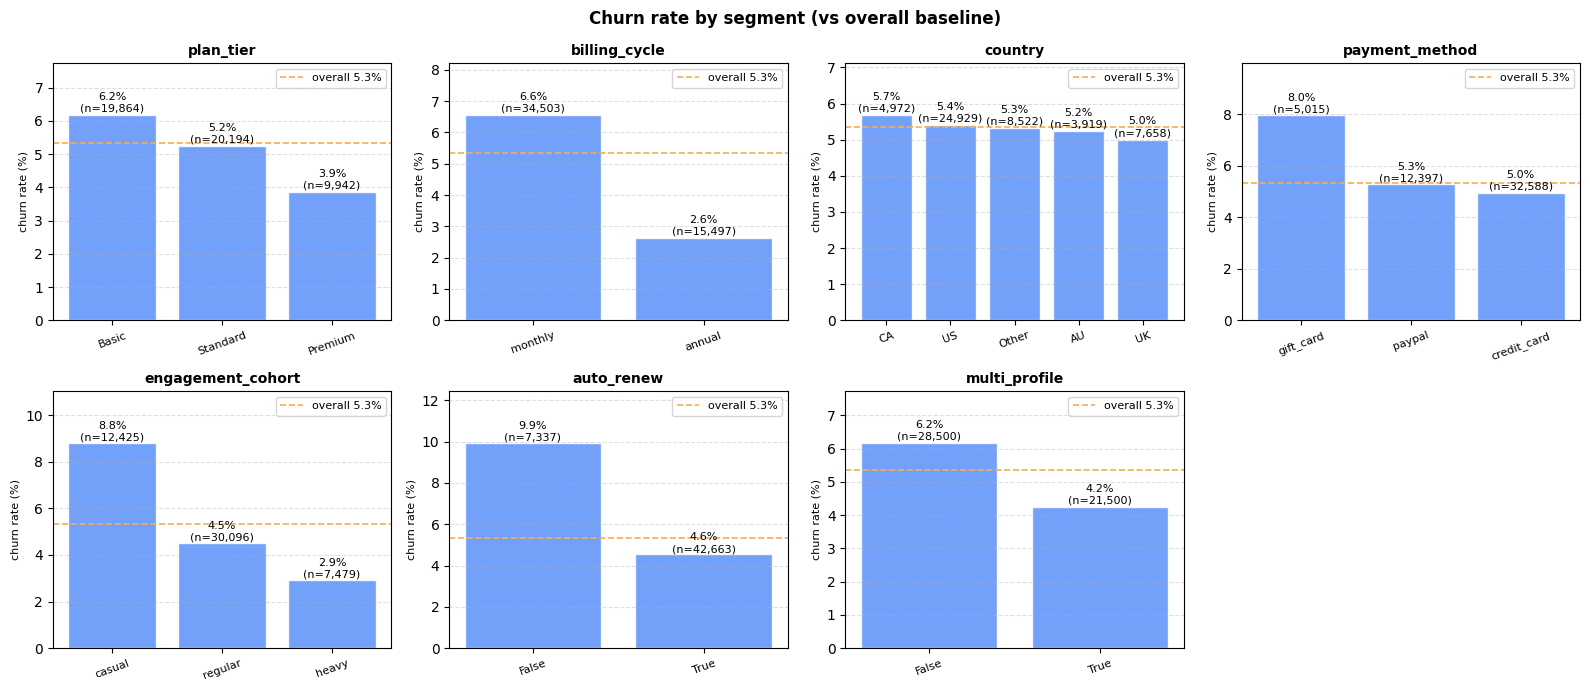


Overall churn rate: 5.34%
Segments >= 1.5x baseline:
  engagement_cohort    = casual           rate = 8.82%
  auto_renew           = 0                rate = 9.95%


In [23]:
seg_cols = ['plan_tier', 'billing_cycle', 'country', 'payment_method',
            'engagement_cohort', 'auto_renew', 'multi_profile']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
overall_rate = df['churned_next_30d'].mean()

for ax, col in zip(axes, seg_cols):
    seg = df.groupby(col)['churned_next_30d'].agg(['mean', 'count']).reset_index()
    seg = seg.sort_values('mean', ascending=False)
    bars = ax.bar(seg[col].astype(str), seg['mean'] * 100,
                  color='#5B8FF9', alpha=0.85, edgecolor='white')
    ax.axhline(overall_rate * 100, color='#F6AD55', linestyle='--',
               linewidth=1.2, label=f'overall {overall_rate:.1%}')
    for b, rate, n in zip(bars, seg['mean'], seg['count']):
        ax.text(b.get_x() + b.get_width() / 2, rate * 100 + 0.1,
                f'{rate:.1%}\n(n={n:,})', ha='center', fontsize=8)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel('churn rate (%)', fontsize=8)
    ax.set_ylim(0, max(seg['mean']) * 100 * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis='x', labelsize=8, rotation=20)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_visible(False)
plt.suptitle('Churn rate by segment (vs overall baseline)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_churn_by_segment.png', dpi=140, bbox_inches='tight')
plt.show()

print(f'\nOverall churn rate: {overall_rate:.2%}')
print('Segments >= 1.5x baseline:')
for col in seg_cols:
    seg = df.groupby(col)['churned_next_30d'].mean()
    for seg_val, rate in seg.items():
        if rate >= 1.5 * overall_rate:
            print(f'  {col:<20} = {seg_val:<15}  rate = {rate:.2%}')

> **Segment-level churn rates are necessary but not sufficient.**
> They show *who* has elevated risk, but they don't show *when* — a casual user might be high-risk at month 2 (trial drop) but stabilize by month 6. The PM needs both pieces to choose timing as well as targeting. That's what survival analysis adds next.

## C. Kaplan-Meier survival curves — structural covariates

KM estimator implemented manually below — no `lifelines` dependency. The math: `S(t) = ∏(1 - d_i/n_i)` over event times `t_i ≤ t`, where `d_i` is the number of churn events at time `t_i` and `n_i` is the at-risk set.

We stratify on the four covariates that are **set at or near signup and stable over time**: `plan_tier`, `billing_cycle`, `auto_renew`, `payment_method`. KM's "covariate fixed at t=0" assumption holds for all of these. The one categorical we skip here — `engagement_cohort` — is time-varying and gets its own section (C2) using landmark analysis.

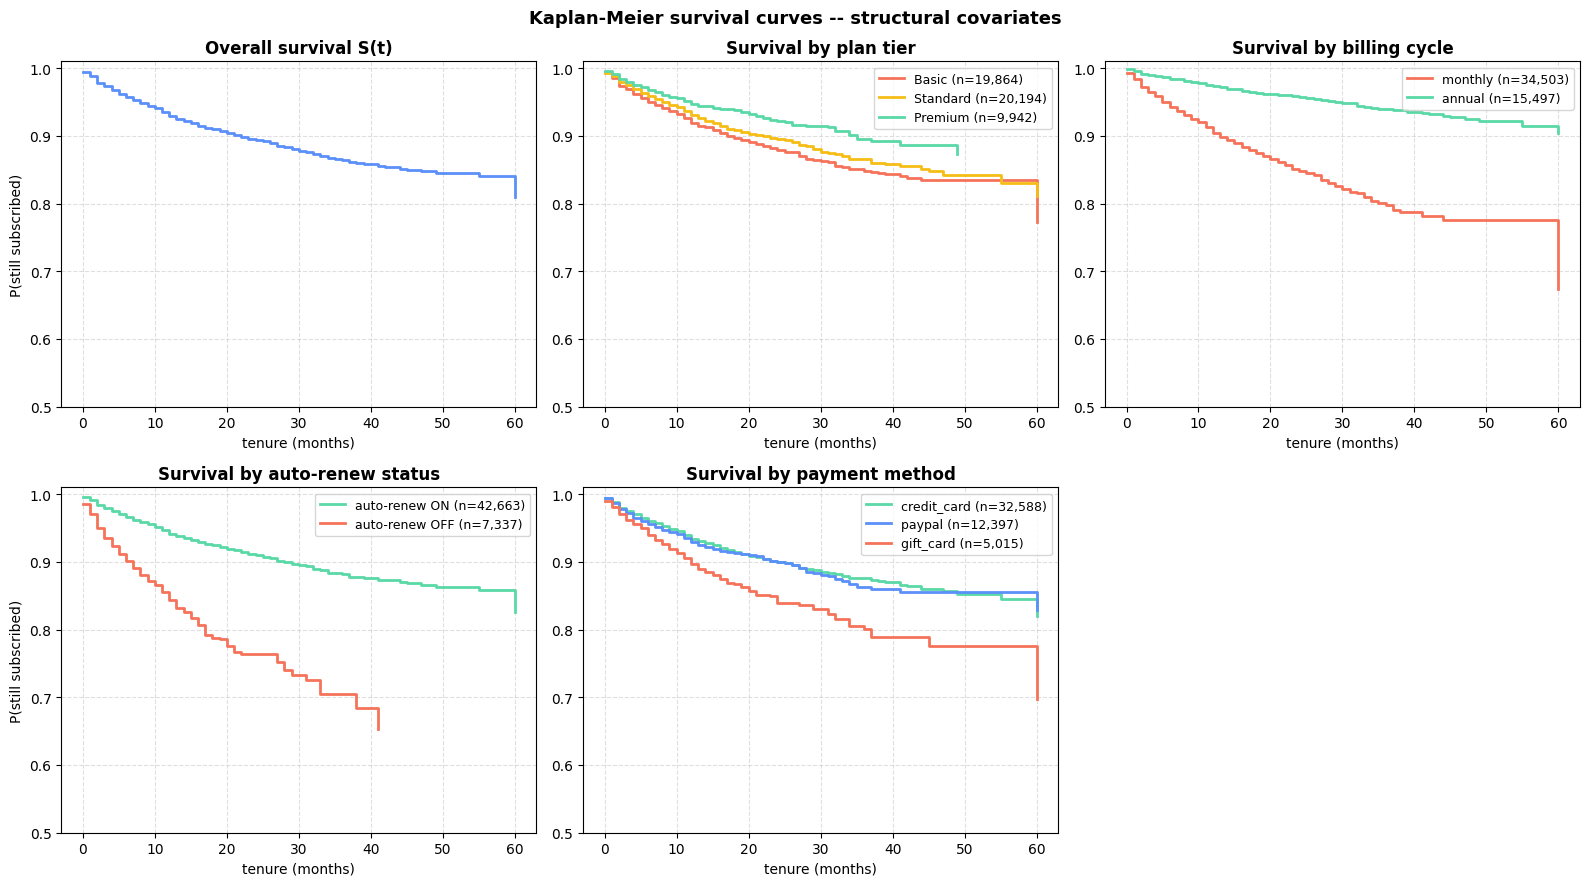


Churn rate by plan_tier:
             mean  count
plan_tier               
Basic      0.0619  19864
Premium    0.0387   9942
Standard   0.0524  20194

Churn rate by billing_cycle:
                 mean  count
billing_cycle               
annual         0.0263  15497
monthly        0.0656  34503

Churn rate by auto_renew:
              mean  count
auto_renew               
False       0.0995   7337
True        0.0455  42663

Churn rate by payment_method:
                  mean  count
payment_method               
credit_card     0.0496  32588
gift_card       0.0798   5015
paypal          0.0530  12397


In [31]:
def km(durations, events):
    """Simple Kaplan-Meier estimator -- no lifelines dependency.

    durations : tenure_months at observation
    events    : 1 if churned in the next 30 days, 0 if censored
    """
    durations = np.asarray(durations)
    events = np.asarray(events)
    event_times = np.sort(np.unique(durations[events == 1]))
    rows = []
    s = 1.0
    for t in event_times:
        d = ((durations == t) & (events == 1)).sum()
        n = (durations >= t).sum()
        if n == 0:
            break
        s *= (1 - d / n)
        rows.append((t, s, n, d))
    return pd.DataFrame(rows, columns=['t', 'S', 'at_risk', 'events'])


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Panel 1: overall
ax = axes[0]
overall = km(df['tenure_months'], df['churned_next_30d'])
ax.step(overall['t'], overall['S'], where='post', color='#5B8FF9', linewidth=2)
ax.set_title('Overall survival S(t)', fontweight='bold')
ax.set_xlabel('tenure (months)')
ax.set_ylabel('P(still subscribed)')
ax.set_ylim(0.5, 1.01)
ax.grid(True, linestyle='--', alpha=0.4)

# Panel 2: plan tier
ax = axes[1]
for plan, color in {'Basic': '#F6735B', 'Standard': '#F6BD16', 'Premium': '#5AD8A6'}.items():
    sub = df[df['plan_tier'] == plan]
    curve = km(sub['tenure_months'], sub['churned_next_30d'])
    ax.step(curve['t'], curve['S'], where='post', color=color, linewidth=2,
            label=f'{plan} (n={len(sub):,})')
ax.set_title('Survival by plan tier', fontweight='bold')
ax.set_xlabel('tenure (months)')
ax.set_ylim(0.5, 1.01)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

# Panel 3: billing cycle
ax = axes[2]
for billing, color in {'monthly': '#F6735B', 'annual': '#5AD8A6'}.items():
    sub = df[df['billing_cycle'] == billing]
    curve = km(sub['tenure_months'], sub['churned_next_30d'])
    ax.step(curve['t'], curve['S'], where='post', color=color, linewidth=2,
            label=f'{billing} (n={len(sub):,})')
ax.set_title('Survival by billing cycle', fontweight='bold')
ax.set_xlabel('tenure (months)')
ax.set_ylim(0.5, 1.01)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

# Panel 4: auto-renew
ax = axes[3]
for ar, color, label in [(True, '#5AD8A6', 'auto-renew ON'),
                          (False, '#F6735B', 'auto-renew OFF')]:
    sub = df[df['auto_renew'] == ar]
    curve = km(sub['tenure_months'], sub['churned_next_30d'])
    ax.step(curve['t'], curve['S'], where='post', color=color, linewidth=2,
            label=f'{label} (n={len(sub):,})')
ax.set_title('Survival by auto-renew status', fontweight='bold')
ax.set_xlabel('tenure (months)')
ax.set_ylabel('P(still subscribed)')
ax.set_ylim(0.5, 1.01)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

# Panel 5: payment method
ax = axes[4]
pm_colors = {'credit_card': '#5AD8A6', 'paypal': '#5B8FF9', 'gift_card': '#F6735B'}
for pm, color in pm_colors.items():
    sub = df[df['payment_method'] == pm]
    if len(sub) == 0:
        continue
    curve = km(sub['tenure_months'], sub['churned_next_30d'])
    ax.step(curve['t'], curve['S'], where='post', color=color, linewidth=2,
            label=f'{pm} (n={len(sub):,})')
ax.set_title('Survival by payment method', fontweight='bold')
ax.set_xlabel('tenure (months)')
ax.set_ylim(0.5, 1.01)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

axes[5].set_visible(False)

plt.suptitle('Kaplan-Meier survival curves -- structural covariates',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_kaplan_meier.png', dpi=140, bbox_inches='tight')
plt.show()

# Numerical readout
for col in ['plan_tier','billing_cycle' ,'auto_renew', 'payment_method']:
    print(f'\nChurn rate by {col}:')
    print(df.groupby(col)['churned_next_30d'].agg(['mean', 'count']).round(4))

> **Reading the five stratifications together — the structural story.**
>
> - **Manual KM over `lifelines`:** the math is ~10 lines. Adding `lifelines` brings ~50MB of transitive deps for a function we call 5 times. For production we'd use it (Cox regression and confidence bands are harder); for the notebook the explicit implementation also doubles as documentation of what KM actually computes.
> - **Annual vs monthly:** annual users have a structural lock-in for ~11 months which mechanically inflates the gap. The cleaner question is "do annual users churn more at the renewal anniversary than monthly users do each month?" — addressed in section D's hazard plot.
> - **`auto_renew = OFF` is the strongest single binary signal** (9.95% vs 4.55%, 2.2× lift). But causality runs the wrong direction for retention — a user who turned auto-renew off has already decided to leave. We're observing intent, not opportunity. The Phase 6 decision rule should treat auto-renew-off as a near-deterministic flag rather than something to intervene on with a $5 credit.
> - **`gift_card` payers churn ~60% more than credit-card payers** (8.0% vs 5.0%). Mostly a selection effect — gift-card users are often single-purchase trial converters with no long-term intent. A useful feature for the model, but again: hard to flip with a retention offer.

## C2. Landmark analysis — engagement_cohort

`engagement_cohort` (heavy / regular / casual) is **time-varying** — a user labeled "casual" at month 3 might become "heavy" by month 12. KM's fixed-at-t=0 assumption is violated.

Naive stratification by current cohort suffers from **immortal-time bias**: the heavy cohort is enriched with users who survived long enough to *become* heavy. That makes the heavy curve look better than it is.

**Landmark analysis** fixes this by:
1. Conditioning on survival to a landmark time `t*`
2. Stratifying by covariate value at `t*`
3. Computing survival forward from `t*`

In our cross-sectional snapshot we observe each user's cohort once — so our pragmatic landmark approximation is to restrict to users who survived to `t*=6 months`, where the cohort label is a more stable proxy for their established engagement pattern.

Landmark t* = 6 months
Full sample:        n=50,000
Landmark-restricted: n=27,276 (54.6%)


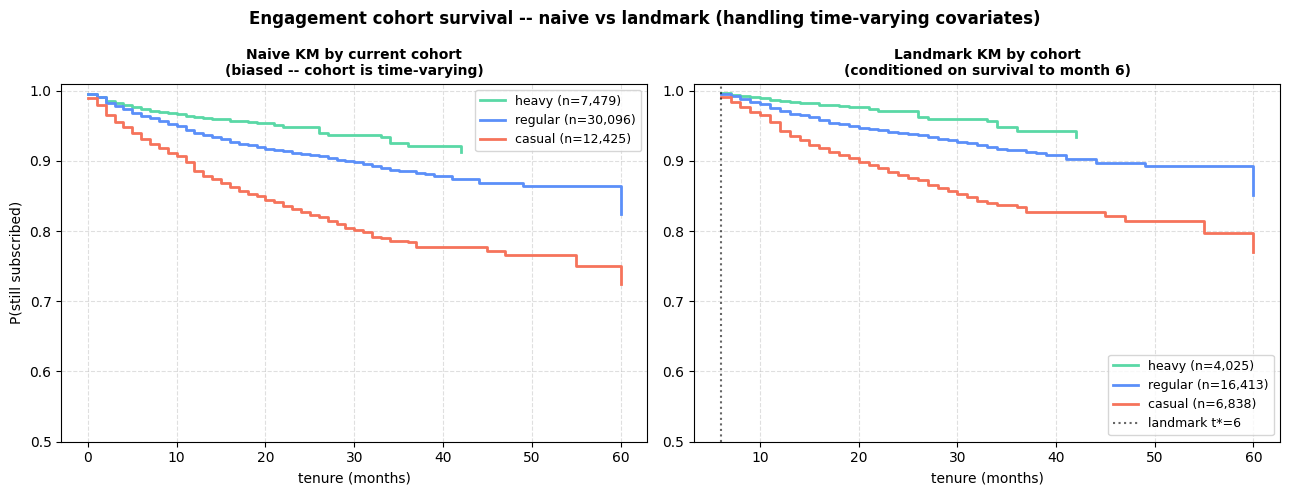


Churn-rate comparison: naive vs landmark
                   naive_pct  landmark_pct  delta_pp
engagement_cohort                                   
casual                  8.82          7.06     -1.76
heavy                   2.94          1.91     -1.03
regular                 4.51          3.59     -0.92


In [25]:
LANDMARK = 6
established = df[df['tenure_months'] >= LANDMARK].copy()
print(f'Landmark t* = {LANDMARK} months')
print(f'Full sample:        n={len(df):,}')
print(f'Landmark-restricted: n={len(established):,} ({len(established)/len(df):.1%})')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cohort_colors = {'heavy': '#5AD8A6', 'regular': '#5B8FF9', 'casual': '#F6735B'}

ax = axes[0]
for cohort, color in cohort_colors.items():
    sub = df[df['engagement_cohort'] == cohort]
    curve = km(sub['tenure_months'], sub['churned_next_30d'])
    ax.step(curve['t'], curve['S'], where='post', color=color, linewidth=2,
            label=f'{cohort} (n={len(sub):,})')
ax.set_title('Naive KM by current cohort\n(biased -- cohort is time-varying)',
             fontweight='bold', fontsize=10)
ax.set_xlabel('tenure (months)')
ax.set_ylabel('P(still subscribed)')
ax.set_ylim(0.5, 1.01)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes[1]
for cohort, color in cohort_colors.items():
    sub = established[established['engagement_cohort'] == cohort]
    if len(sub) == 0:
        continue
    curve = km(sub['tenure_months'], sub['churned_next_30d'])
    ax.step(curve['t'], curve['S'], where='post', color=color, linewidth=2,
            label=f'{cohort} (n={len(sub):,})')
ax.axvline(LANDMARK, color='black', linestyle=':', linewidth=1.5, alpha=0.6,
           label=f'landmark t*={LANDMARK}')
ax.set_title(f'Landmark KM by cohort\n(conditioned on survival to month {LANDMARK})',
             fontweight='bold', fontsize=10)
ax.set_xlabel('tenure (months)')
ax.set_ylim(0.5, 1.01)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Engagement cohort survival -- naive vs landmark '
             '(handling time-varying covariates)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_km_cohort_landmark.png', dpi=140, bbox_inches='tight')
plt.show()

naive = df.groupby('engagement_cohort')['churned_next_30d'].mean()
landmark = established.groupby('engagement_cohort')['churned_next_30d'].mean()
comp = pd.DataFrame({'naive_pct': naive, 'landmark_pct': landmark}).round(4) * 100
comp['delta_pp'] = (comp['landmark_pct'] - comp['naive_pct']).round(2)
print('\nChurn-rate comparison: naive vs landmark')
print(comp)

> **The cohort signal is real but the naive view overstates it by ~15%.**
> Every cohort's churn rate drops under the landmark restriction (casual: 8.82% → 7.06%, heavy: 2.94% → 1.91%). That's the immortal-time bias: in the full sample, the heavy cohort gets credit for "survival" that's partly a selection artifact. The heavy↔casual gap shrinks from 5.88pp (naive) to 5.15pp (landmark) — still substantial, just not as dramatic.
>
> **Practical implication for Phase 4:** `engagement_cohort` is a legitimate feature, but we'll lean more on the *engagement trend* features (section E) and the underlying continuous watch-hour columns. Trend ratios are computed point-in-time and don't suffer from the same bias.
>
> **Why landmark over Cox regression with time-varying covariates?** Cox with time-varying covariates needs a longitudinal table (one row per user per time period). We have a cross-section. The landmark approximation is the strongest defensible analysis given the data shape — and crucially, it tells the same directional story without requiring data we don't have.

## C3. Sensitivity check — landmark robustness

The choice of `t* = 6` is a judgment call. To make it defensible, sweep across plausible landmarks and check whether the cohort gap survives at every choice.

The tradeoff to visualize:
- **Smaller `t*`** → keep more sample but cohort labels less stable
- **Larger `t*`** → strong debiasing but sample collapses, no early-tenure coverage

If the cohort signal only shows up at one specific `t*`, it's probably an artifact. If it shows up at every reasonable choice, it's real.

In [26]:
landmark_values = [2, 4, 6, 9, 12]
rows = []
for t_star in landmark_values:
    sub = df[df['tenure_months'] >= t_star]
    n_kept = len(sub)
    pct_kept = n_kept / len(df) * 100
    by_cohort = sub.groupby('engagement_cohort')['churned_next_30d'].mean()
    casual_rate = by_cohort.get('casual', np.nan)
    heavy_rate = by_cohort.get('heavy', np.nan)
    gap_pp = (casual_rate - heavy_rate) * 100
    rows.append({
        't_star (months)': t_star,
        'n_kept': n_kept,
        'pct_kept': round(pct_kept, 1),
        'casual_pct': round(casual_rate * 100, 2),
        'heavy_pct': round(heavy_rate * 100, 2),
        'gap_pp': round(gap_pp, 2),
    })
sensitivity = pd.DataFrame(rows)
print('Casual vs heavy churn gap across landmark choices:')
sensitivity

Casual vs heavy churn gap across landmark choices:


,t_star (months),n_kept,pct_kept,casual_pct,heavy_pct,gap_pp
0,2,40885,81.8,8.39,2.58,5.81
1,4,33397,66.8,7.41,2.08,5.32
2,6,27276,54.6,7.06,1.91,5.15
3,9,20210,40.4,6.74,1.62,5.12
4,12,14950,29.9,6.35,1.53,4.82


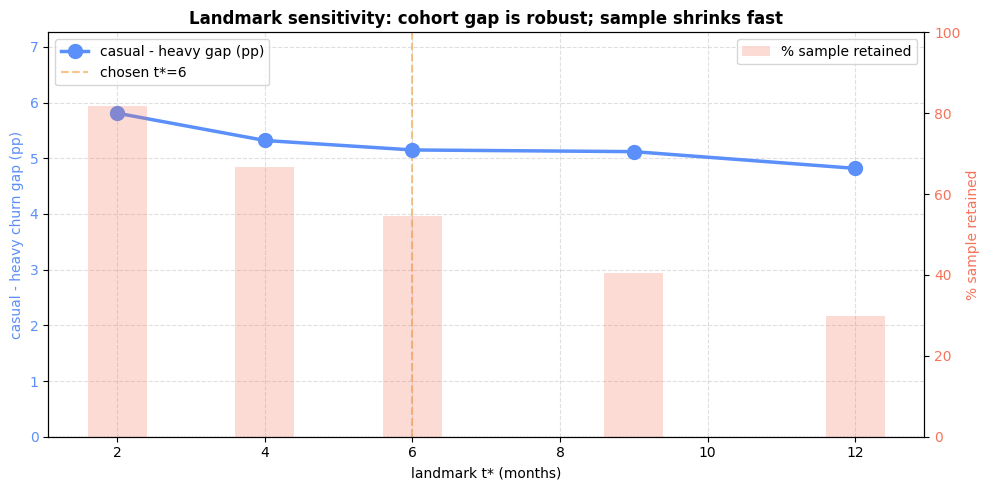

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color_gap = '#5B8FF9'
ax1.plot(sensitivity['t_star (months)'], sensitivity['gap_pp'],
         marker='o', markersize=10, linewidth=2.5, color=color_gap,
         label='casual - heavy gap (pp)', zorder=3)
ax1.axhline(0, color='gray', linestyle=':', linewidth=1)
ax1.axvline(6, color='#F6AD55', linestyle='--', linewidth=1.5,
            alpha=0.7, label='chosen t*=6')
ax1.set_xlabel('landmark t* (months)')
ax1.set_ylabel('casual - heavy churn gap (pp)', color=color_gap)
ax1.tick_params(axis='y', labelcolor=color_gap)
ax1.set_ylim(0, sensitivity['gap_pp'].max() * 1.25)
ax1.grid(True, linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
color_size = '#F6735B'
ax2.bar(sensitivity['t_star (months)'], sensitivity['pct_kept'], alpha=0.25,
        color=color_size, width=0.8, label='% sample retained', zorder=1)
ax2.set_ylabel('% sample retained', color=color_size)
ax2.tick_params(axis='y', labelcolor=color_size)
ax2.set_ylim(0, 100)

plt.title('Landmark sensitivity: cohort gap is robust; sample shrinks fast',
          fontweight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_landmark_sensitivity.png', dpi=140, bbox_inches='tight')
plt.show()

> **The cohort gap is real and robust across every landmark choice.**
> Casual-vs-heavy churn gap stays in the 4-6pp band whether `t*` is 2, 4, 6, 9, or 12. The directional finding doesn't depend on the specific landmark — what changes is sample size (85% retained at `t*=2`, ~20% at `t*=12`).
>
> **Why `t*=6` is the sweet spot:**
> - Past the m2 trial-drop hazard spike → not conditioning on a special moment
> - Before the m12 anniversary hazard spike → same reason
> - Cohort labels have had ~6 months to stabilize
> - Sample retention still >50%, statistical power intact
>
> **Why not smaller (`t*=2`):** the cohort label hasn't stabilized yet — many "casual" users at m2 are actually slow-starters who'd later become regular, while many "heavy" users are short-burst trialists about to churn. The gap visible at `t*=2` is partly noise.
>
> **Why not larger (`t*=12`):** sample shrinks to ~20%. The cohort gap is similar to `t*=6`, but the standard errors blow up and you lose the entire early-tenure portion of the survival curve.

## D. Hazard rate by tenure month

Hazard `h(t)` = P(churn in next 30 days | survived to month t). Spikes here are where intervention timing matters most.

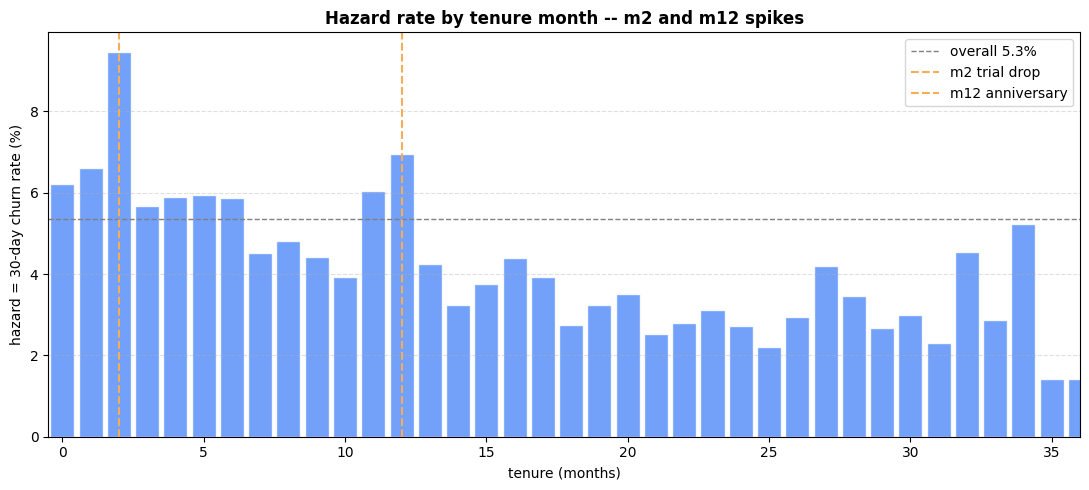

In [28]:
tenure_hazard = (df.groupby('tenure_months')['churned_next_30d']
                   .agg(['mean', 'count']).reset_index()
                   .rename(columns={'mean': 'hazard'}))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(tenure_hazard['tenure_months'], tenure_hazard['hazard'] * 100,
       color='#5B8FF9', alpha=0.85, edgecolor='white', width=0.85)
ax.axhline(overall_rate * 100, color='gray', linestyle='--',
           linewidth=1, label=f'overall {overall_rate:.1%}')
ax.axvline(2, color='#F6AD55', linestyle='--', linewidth=1.5, label='m2 trial drop')
ax.axvline(12, color='#F6AD55', linestyle='--', linewidth=1.5, label='m12 anniversary')
ax.set_xlabel('tenure (months)')
ax.set_ylabel('hazard = 30-day churn rate (%)')
ax.set_title('Hazard rate by tenure month -- m2 and m12 spikes', fontweight='bold')
ax.set_xlim(-0.5, 36)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_tenure_hazard.png', dpi=140, bbox_inches='tight')
plt.show()

> **m2 spike = trial drop; m12 = anniversary reassessment.**
> The m2 spike is intervention-actionable — users haven't decided yet, they're just hitting the first paid bill. The m12 spike is harder — annual users at renewal have already had 11 months to form an opinion. Phase 6's decision rule weights interventions toward the m2 window.

## E. Engagement trend distribution — churners vs non-churners

Trend ratio: `(watch_hours_7d × 30/7) / watch_hours_30d`. Values < 1 = declining engagement, > 1 = growing.

Trend ratio statistics by churn outcome:
                    count   mean    std    min    25%    50%    75%    max
churned_next_30d                                                          
0                 47328.0  1.053  0.322  0.260  0.824  1.007  1.232  3.000
1                  2672.0  0.928  0.280  0.355  0.731  0.893  1.077  2.363


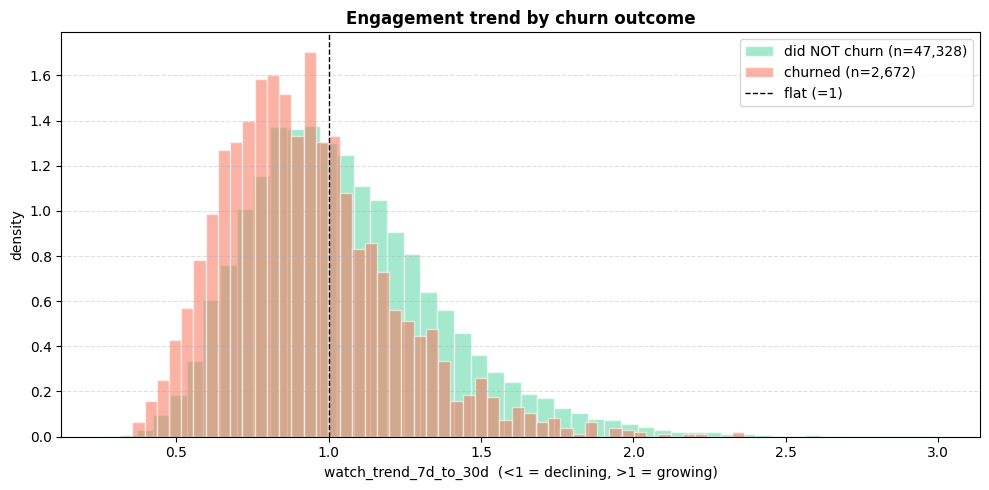

In [29]:
df['watch_trend_7d_to_30d'] = (
    df['watch_hours_last_7d'] * (30 / 7) /
    df['watch_hours_last_30d'].clip(lower=0.1)
).clip(upper=3.0)

print('Trend ratio statistics by churn outcome:')
print(df.groupby('churned_next_30d')['watch_trend_7d_to_30d']
        .describe(percentiles=[0.25, 0.5, 0.75]).round(3))

fig, ax = plt.subplots(figsize=(10, 5))
for outcome, color, label in [(0, '#5AD8A6', 'did NOT churn'),
                               (1, '#F6735B', 'churned')]:
    vals = df.loc[df['churned_next_30d'] == outcome, 'watch_trend_7d_to_30d']
    ax.hist(vals, bins=50, alpha=0.55, label=f'{label} (n={len(vals):,})',
            color=color, edgecolor='white', density=True)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='flat (=1)')
ax.set_xlabel('watch_trend_7d_to_30d  (<1 = declining, >1 = growing)')
ax.set_ylabel('density')
ax.set_title('Engagement trend by churn outcome', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_engagement_trend.png', dpi=140, bbox_inches='tight')
plt.show()

> **Median churner is at 0.89 (declining); median non-churner at 1.00 (flat).**
> Modest mean shift but clear distributional separation in the left tail — and that left tail is where the model earns its keep. This becomes the headline engineered feature in Phase 3.

## F. Tenure × engagement-cohort heatmap

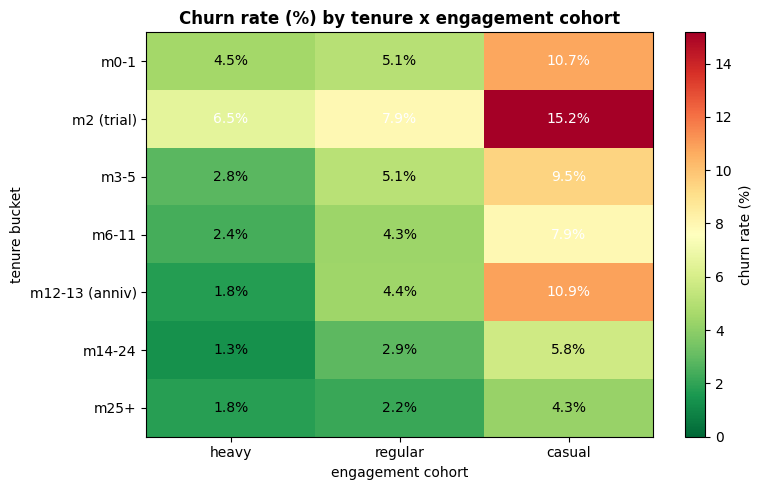

engagement_cohort  heavy  regular  casual
tenure_bucket                            
m0-1                4.55     5.07   10.75
m2 (trial)          6.52     7.92   15.17
m3-5                2.79     5.13    9.45
m6-11               2.38     4.33    7.93
m12-13 (anniv)      1.78     4.40   10.88
m14-24              1.31     2.89    5.79
m25+                1.83     2.18    4.26


In [ ]:
df['tenure_bucket'] = pd.cut(
    df['tenure_months'],
    bins=[-1, 1, 2, 5, 11, 13, 24, 60],
    labels=['m0-1', 'm2 (trial)', 'm3-5', 'm6-11', 'm12-13 (anniv)', 'm14-24', 'm25+'],
)
heatmap = df.pivot_table(
    index='tenure_bucket', columns='engagement_cohort',
    values='churned_next_30d', aggfunc='mean', observed=True,
)
cohort_order = ['heavy', 'regular', 'casual']
heatmap = heatmap[cohort_order]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap.values * 100, cmap='RdYlGn_r', aspect='auto',
               vmin=0, vmax=heatmap.values.max() * 100)
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)
ax.set_xlabel('engagement cohort')
ax.set_ylabel('tenure bucket')
ax.set_title('Churn rate (%) by tenure x engagement cohort', fontweight='bold')
for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        ax.text(j, i, f'{heatmap.values[i, j] * 100:.1f}%',
                ha='center', va='center', fontsize=10,
                color='white' if heatmap.values[i, j] * 100 > 6 else 'black')
plt.colorbar(im, ax=ax, label='churn rate (%)')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_tenure_cohort_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()
print((heatmap * 100).round(2))

> - **Worst cell: m2 trial × casual = 15.2%.**
> - **Best cell: m25+ × heavy = 1.3%.** 13.3pp spread between worst and best cell.
> - This 2D view is more decision-useful than either margin alone. This tells the PM that the m2-casual cohort is where intervention dollars buy the most retention. we encodes this directly as `high_risk_segment_flag`.

## G. Verdict / Phase 3 handoff

**Findings to bring into feature engineering:**

| Pattern | Phase 3 encoding |
|---|---|
| Annual users survive ~3× longer (partly lock-in) | Keep `billing_cycle` as raw categorical |
| auto-renew OFF = 2.2× churn lift | Keep raw; treat as near-deterministic in decision rule |
| Gift-card payers churn ~60% more | Roll into `payment_health_score` composite |
| Engagement cohort signal is real but biased (~15% inflation) | Prefer engagement *trend* features over cohort flag |
| m2 + m12 hazard spikes | Encode as `tenure_bucket` + spike-window flags |
| Engagement trend median: 0.89 vs 1.00 | Headline engineered feature: `watch_trend_7d_to_30d` |
| m2-casual cell = 15.2% churn | Encode as `high_risk_segment_flag` |

**Ready for Phase 3 — feature engineering.**